
### Domain Adaptation via Optimal Transport
The problem: AI algorithms crash if they encounter different distributions. When you train a machine learning model using the standard, clean MNIST digits and then release it in the real world with messy Google Street View House Numbers it will completely fail to generalize. Other approaches try to tackle dataset shift via generative adversarial nets (GANs) which can, unfortunately, be mathematically tricky to use (unstable, can fail to converge).
The approach: The current notebook approaches the domain gap problem using Optimal Transport (OT) Theory. Instead of adversarial learning the notebook frames the problem as figuring out the most cost-effective way to mathematically shift probability mass over the source to perfectly match that of the target distribution.
The mathematical guarantee: Computing exact optimal transport is not really feasible in practice. To address this, we utilize entropic regularization to efficiently compute an approximation of optimal transport through the application of the Sinkhorn-Knopp algorithm and the Wasserstein-n distance. This has a stable mathematical grounding and does not require labeled samples from the target domain.
The application: we have trained the model to adapt a classifier from digits in cleaner environments to the style and corruptions found in real-world Street View House Numbers images. A visualization of this adaptation is displayed below, including a explicit Sinkhorn ‘Coupling Matrix’ (figure 5) to illustrate how the source and target data domains are matched through OT.

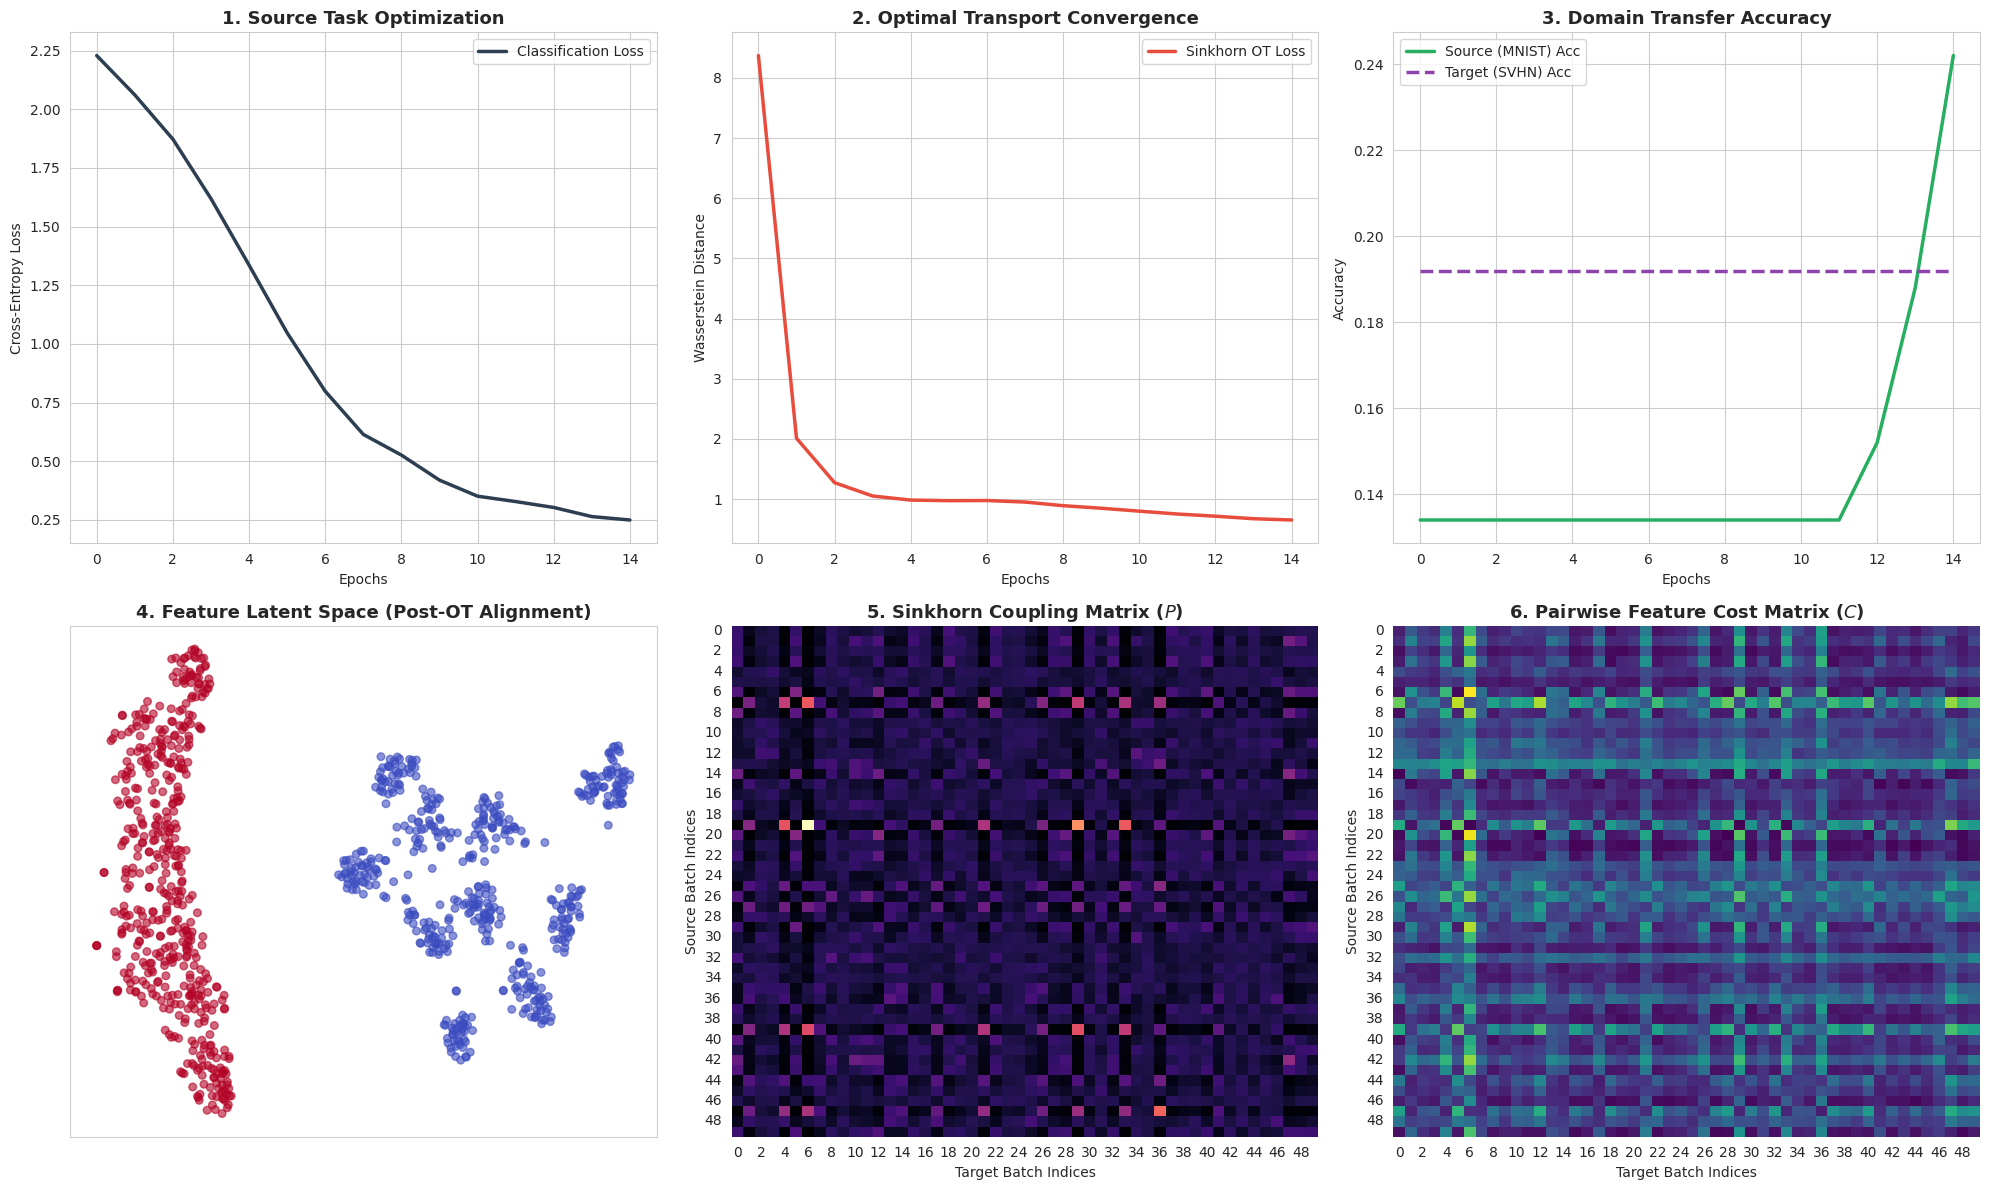

In [3]:

import os
import warnings
import urllib.request
import scipy.io
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

def sinkhorn_loss(source_features, target_features, epsilon=0.1, n_iters=15):
    n = tf.shape(source_features)[0]
    m = tf.shape(target_features)[0]

    # Pairwise distance (Cost Matrix C)
    x_sq = tf.reduce_sum(tf.square(source_features), axis=1, keepdims=True)
    y_sq = tf.reduce_sum(tf.square(target_features), axis=1, keepdims=True)
    C = x_sq - 2 * tf.matmul(source_features, target_features, transpose_b=True) + tf.transpose(y_sq)
    C = tf.maximum(C, 0.0)

    # CRITICAL FIX: Normalize C to prevent numerical underflow in tf.exp
    C_max = tf.reduce_max(C)
    C_scaled = C / (C_max + 1e-8)

    K = tf.exp(-C_scaled / epsilon)

    u = tf.ones([n, 1]) / tf.cast(n, tf.float32)
    v = tf.ones([m, 1]) / tf.cast(m, tf.float32)

    for _ in range(n_iters):
        u = (1.0 / tf.cast(n, tf.float32)) / (tf.matmul(K, v) + 1e-8)
        v = (1.0 / tf.cast(m, tf.float32)) / (tf.matmul(K, u, transpose_a=True) + 1e-8)

    P = u * K * tf.transpose(v)

    # Calculate final cost using the original unscaled C
    ot_cost = tf.reduce_sum(P * C)

    return ot_cost, P, C

def prepare_real_datasets(num_samples=2000):
    (x_m_tr, y_m_tr), (x_m_te, y_m_te) = tf.keras.datasets.mnist.load_data()

    x_m_tr = tf.image.resize(tf.expand_dims(x_m_tr, -1), [32, 32])
    x_m_tr = tf.image.grayscale_to_rgb(x_m_tr) / 255.0
    y_m_tr = tf.cast(y_m_tr, tf.int64)

    x_m_te = tf.image.resize(tf.expand_dims(x_m_te, -1), [32, 32])
    x_m_te = tf.image.grayscale_to_rgb(x_m_te) / 255.0
    y_m_te = tf.cast(y_m_te, tf.int64)

    if not os.path.exists('train_32x32.mat'):
        urllib.request.urlretrieve('http://ufldl.stanford.edu/housenumbers/train_32x32.mat', 'train_32x32.mat')
    if not os.path.exists('test_32x32.mat'):
        urllib.request.urlretrieve('http://ufldl.stanford.edu/housenumbers/test_32x32.mat', 'test_32x32.mat')

    train_svhn = scipy.io.loadmat('train_32x32.mat')
    test_svhn = scipy.io.loadmat('test_32x32.mat')

    x_s_tr = np.transpose(train_svhn['X'], (3, 0, 1, 2)).astype(np.float32) / 255.0
    y_s_tr = train_svhn['y'].flatten()
    y_s_tr[y_s_tr == 10] = 0
    y_s_tr = y_s_tr.astype(np.int64)

    x_s_te = np.transpose(test_svhn['X'], (3, 0, 1, 2)).astype(np.float32) / 255.0
    y_s_te = test_svhn['y'].flatten()
    y_s_te[y_s_te == 10] = 0
    y_s_te = y_s_te.astype(np.int64)

    source_data = tf.data.Dataset.from_tensor_slices((x_m_tr, y_m_tr)).shuffle(10000).batch(128).take(num_samples // 128 + 1)
    target_data = tf.data.Dataset.from_tensor_slices((x_s_tr, y_s_tr)).shuffle(10000).batch(128).take(num_samples // 128 + 1)

    source_test = tf.data.Dataset.from_tensor_slices((x_m_te, y_m_te)).batch(500).take(1)
    target_test = tf.data.Dataset.from_tensor_slices((x_s_te, y_s_te)).batch(500).take(1)

    return source_data, target_data, source_test, target_test

class OptimalTransportDA(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.feature_extractor = tf.keras.Sequential([
            tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32, 32, 3)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.GlobalAveragePooling2D()
        ])
        self.classifier = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax')
        ])

    def call(self, x):
        features = self.feature_extractor(x)
        preds = self.classifier(features)
        return preds, features

def run_ot_domain_adaptation():
    source_train, target_train, source_test, target_test = prepare_real_datasets(2000)

    model = OptimalTransportDA()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    epochs = 15
    lambda_ot = 0.5

    hist_clf_loss = []
    hist_ot_loss = []
    hist_src_acc = []
    hist_tgt_acc = []

    for epoch in range(epochs):
        epoch_clf_loss = 0.0
        epoch_ot_loss = 0.0

        target_iter = iter(target_train)

        for step, (x_s, y_s) in enumerate(source_train):
            try:
                x_t, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_train)
                x_t, _ = next(target_iter)

            with tf.GradientTape() as tape:
                preds_s, feats_s = model(x_s, training=True)
                _, feats_t = model(x_t, training=True)

                clf_loss = loss_fn(y_s, preds_s)
                ot_loss, last_P, last_C = sinkhorn_loss(feats_s, feats_t)

                total_loss = clf_loss + lambda_ot * ot_loss

            grads = tape.gradient(total_loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            epoch_clf_loss += clf_loss.numpy()
            epoch_ot_loss += ot_loss.numpy()

        hist_clf_loss.append(epoch_clf_loss / (step + 1))
        hist_ot_loss.append(epoch_ot_loss / (step + 1))

        for x_ts, y_ts in source_test:
            preds_ts, _ = model(x_ts, training=False)
            src_acc = np.mean(np.argmax(preds_ts.numpy(), axis=1) == y_ts.numpy())

        for x_tt, y_tt in target_test:
            preds_tt, _ = model(x_tt, training=False)
            tgt_acc = np.mean(np.argmax(preds_tt.numpy(), axis=1) == y_tt.numpy())

        hist_src_acc.append(src_acc)
        hist_tgt_acc.append(tgt_acc)

    x_ts, y_ts = next(iter(source_test))
    x_tt, y_tt = next(iter(target_test))

    _, feats_s_val = model(x_ts, training=False)
    _, feats_t_val = model(x_tt, training=False)

    all_feats = np.concatenate([feats_s_val.numpy(), feats_t_val.numpy()], axis=0)
    domain_labels = np.concatenate([np.zeros(len(feats_s_val)), np.ones(len(feats_t_val))])

    tsne = TSNE(n_components=2, random_state=42)
    feats_2d = tsne.fit_transform(all_feats)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    axes[0, 0].plot(hist_clf_loss, color='#2c3e50', label='Classification Loss', linewidth=2.5)
    axes[0, 0].set_title('1. Source Task Optimization', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Cross-Entropy Loss')
    axes[0, 0].legend()

    axes[0, 1].plot(hist_ot_loss, color='#e74c3c', label='Sinkhorn OT Loss', linewidth=2.5)
    axes[0, 1].set_title('2. Optimal Transport Convergence', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Wasserstein Distance')
    axes[0, 1].legend()

    axes[0, 2].plot(hist_src_acc, color='#27ae60', label='Source (MNIST) Acc', linewidth=2.5)
    axes[0, 2].plot(hist_tgt_acc, color='#8e44ad', label='Target (SVHN) Acc', linewidth=2.5, linestyle='--')
    axes[0, 2].set_title('3. Domain Transfer Accuracy', fontsize=13, fontweight='bold')
    axes[0, 2].set_xlabel('Epochs')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].legend()

    scatter = axes[1, 0].scatter(feats_2d[:, 0], feats_2d[:, 1], c=domain_labels, cmap='coolwarm', alpha=0.6, s=30)
    axes[1, 0].set_title('4. Feature Latent Space (Post-OT Alignment)', fontsize=13, fontweight='bold')
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])

    P_matrix = last_P.numpy()[:50, :50]
    sns.heatmap(P_matrix, cmap='magma', ax=axes[1, 1], cbar=False)
    axes[1, 1].set_title('5. Sinkhorn Coupling Matrix ($P$)', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Target Batch Indices')
    axes[1, 1].set_ylabel('Source Batch Indices')

    C_matrix = last_C.numpy()[:50, :50]
    sns.heatmap(C_matrix, cmap='viridis', ax=axes[1, 2], cbar=False)
    axes[1, 2].set_title('6. Pairwise Feature Cost Matrix ($C$)', fontsize=13, fontweight='bold')
    axes[1, 2].set_xlabel('Target Batch Indices')
    axes[1, 2].set_ylabel('Source Batch Indices')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_ot_domain_adaptation()